In [2]:
# Data handling
import pandas as pd 
import numpy as np 

# Model selection and evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score

# Statistics
import scipy.stats as stats

# Visualization
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns 

# Models
from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier

# Preprocessing
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer


In [3]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [4]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
df.fillna({'Age': df['Age'].mean()}, inplace=True)


In [6]:
x = df.iloc[:,1:3]
y = df.iloc[:,0]

In [7]:
xtrain , xtest , ytrain, ytest = train_test_split(x,y,test_size=0.3,random_state=42)

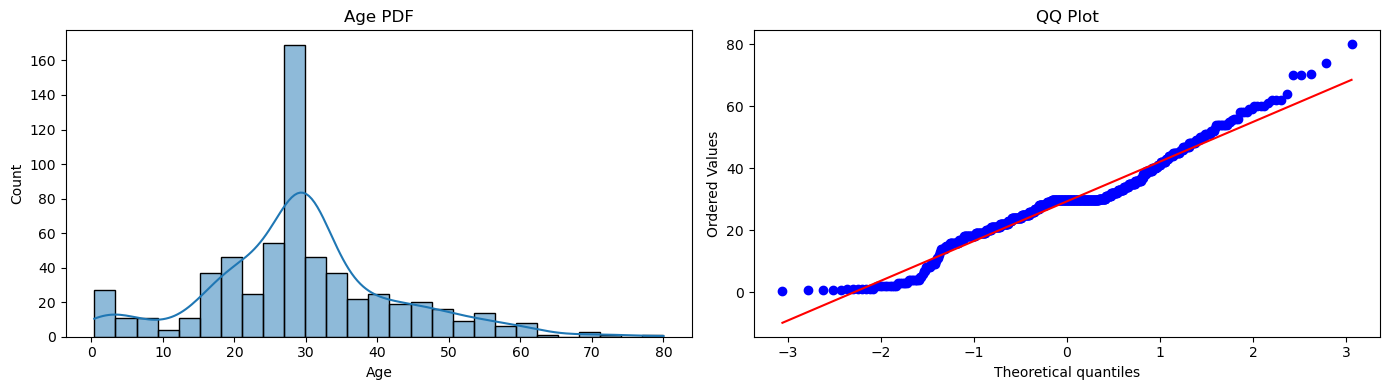

In [8]:
plt.figure(figsize=(14, 4))

# PDF (Histogram + KDE)
plt.subplot(1, 2, 1)
sns.histplot(xtrain['Age'], kde=True)
plt.title('Age PDF')

# QQ Plot
plt.subplot(1, 2, 2)
stats.probplot(xtrain['Age'], dist="norm", plot=plt)
plt.title('QQ Plot')

plt.tight_layout()
plt.show()


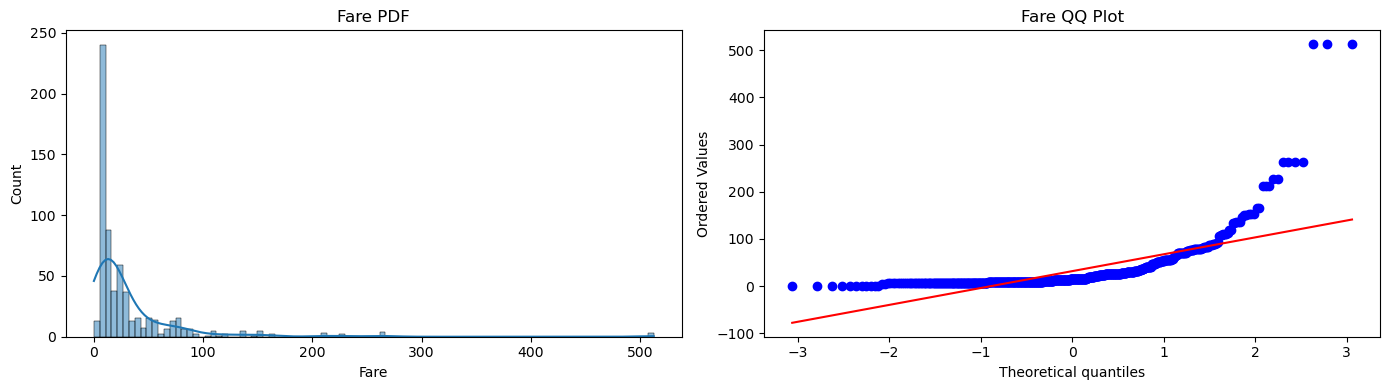

In [9]:
plt.figure(figsize=(14, 4))

# Fare PDF
plt.subplot(1, 2, 1)
sns.histplot(xtrain['Fare'], kde=True)
plt.title('Fare PDF')

# Fare QQ Plot
plt.subplot(1, 2, 2)
stats.probplot(xtrain['Fare'], dist="norm", plot=plt)
plt.title('Fare QQ Plot')

plt.tight_layout()
plt.show()

In [10]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [11]:
clf.fit(xtrain,ytrain)
clf2.fit(xtrain,ytrain)
    
ypred = clf.predict(xtest)
ypred1 = clf2.predict(xtest)
    
print("Accuracy LR",accuracy_score(ytest,ypred))
print("Accuracy DT",accuracy_score(ytest,ypred1))

Accuracy LR 0.6529850746268657
Accuracy DT 0.6828358208955224


In [12]:
trf = FunctionTransformer(func=np.log1p)


In [13]:

xtrain_transformed = trf.fit_transform(xtrain)
xtest_transformed = trf.transform(xtest)

In [14]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()



In [15]:
clf.fit(xtrain_transformed,ytrain)
clf2.fit(xtrain_transformed,ytrain)
    
y_pred = clf.predict(xtest_transformed)
y_pred1 = clf2.predict(xtest_transformed)
    
print("Accuracy LR",accuracy_score(ytest,ypred))
print("Accuracy DT",accuracy_score(ytest,ypred1))

Accuracy LR 0.6529850746268657
Accuracy DT 0.6828358208955224


In [16]:
X_transformed = trf.fit_transform(x)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv=10)))

LR 0.678027465667915
DT 0.6667166042446943
